### Find epilines corresponding points between two views
 - Detect and match feature points
   - Use SIFT or ORB to detect feature points, then perform descriptor matching
 - Use RANSAC to find the fundamental matrix
   - Use cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC) to estimate 𝐹
 - Compute and draw epilines
   - Use cv2.computeCorrespondEpilines to calculate epilines and draw them on the image

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img1 = cv2.imread('./images/left.jpg',0)  #queryimage # left image
img2 = cv2.imread('./images/right.jpg',0) #trainimage # right image

sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

# Get two closest matches for each keypoint
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

good = []
pts1 = []
pts2 = []

# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.8*n.distance:
        good.append(m)
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)


In [2]:
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)
F, mask = cv2.findFundamentalMat(pts1,pts2,cv2.FM_RANSAC)#Find corespondence

# We select only inlier points (remove outliers points)
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]


In [3]:
F

array([[-3.00263243e-06,  2.51971655e-05, -8.20020396e-05],
       [ 6.75309899e-05, -8.49807369e-06, -4.41270397e-02],
       [-4.16016169e-03,  2.13888670e-02,  1.00000000e+00]])

In [4]:
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2,cv2.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv2.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv2.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv2.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2


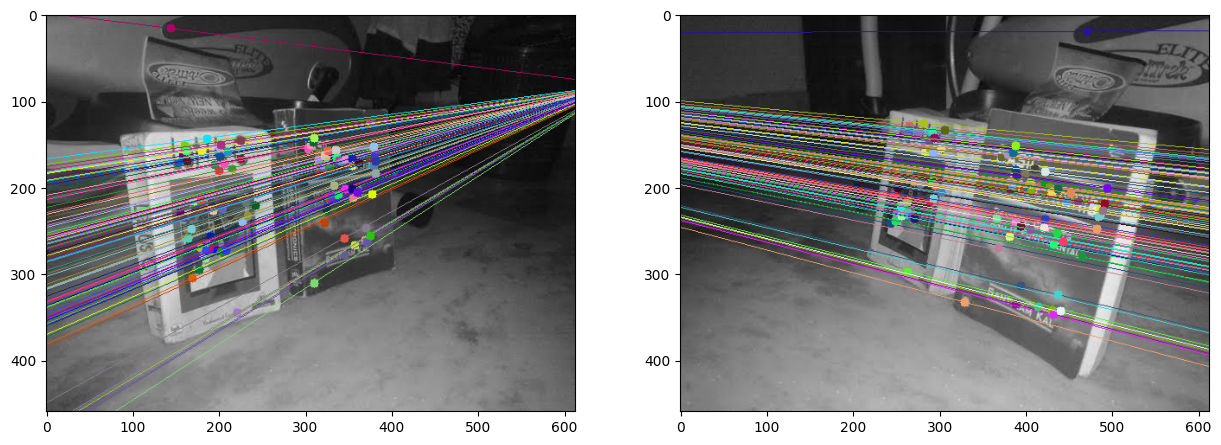

In [5]:
# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1,1,2),2,F)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawlines(img1,img2,lines1,pts1,pts2)

# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1,1,2),1,F)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawlines(img2,img1,lines2,pts2,pts1)

plt.figure(figsize=(15,10))
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()


### Compute depth map from stereo images
 - Input two rectified left and right images
   - Rectify to ensure that disparity varies primarily along the horizontal line
 - Calculate the disparity map
   - Use OpenCV's StereoSGBM or StereoBM
 - Convert to a depth map

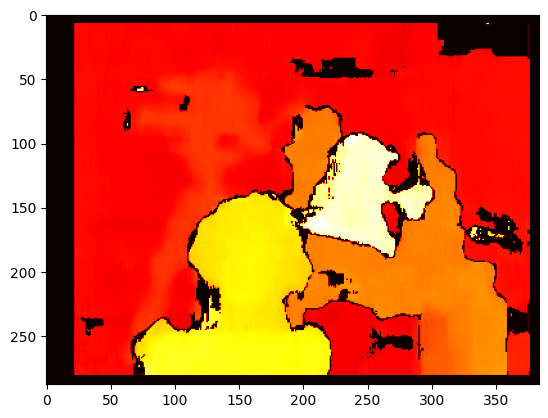

In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

imgL = cv2.imread('./images/tsukuba_l.png',0)
imgR = cv2.imread('./images/tsukuba_r.png',0)

stereo = cv2.StereoBM_create(numDisparities= 16,blockSize=15)
disparity = stereo.compute(imgL,imgR)
plt.imshow(disparity,cmap='hot')
plt.show()


## Python impelementation

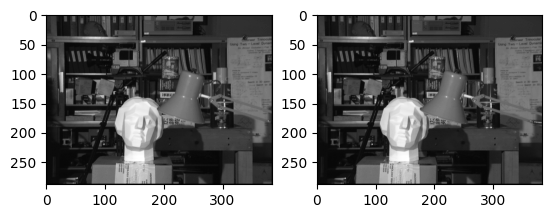

In [7]:
left_im = cv2.imread('./images/tsukuba_l.png', 0)
right_im = cv2.imread('./images/tsukuba_r.png', 0)

left_im_array = np.asarray(left_im).astype(int)
right_im_array = np.asarray(right_im).astype(int)
f, axes = plt.subplots(1,2)
axes[0].imshow(left_im, cmap="gray")
axes[1].imshow(right_im, cmap="gray")

In [8]:
left_im.shape

(288, 384)

In [30]:
def sum_of_abs_diff(pixel_vals_1, pixel_vals_2):
    """
    Args:
        pixel_vals_1 (numpy.ndarray): pixel block from left image
        pixel_vals_2 (numpy.ndarray): pixel block from right image
    Returns:
        float: Sum of absolute difference between individual pixels
    """
    if pixel_vals_1.shape != pixel_vals_2.shape:
        return -1

    return np.sum(abs(pixel_vals_1 - pixel_vals_2))

In [ ]:
def compare_blocks(y, x, block_left, right_array, block_size, SEARCH_BLOCK_SIZE):
    """
    Compare left block of pixels with multiple blocks from the right
    image using SEARCH_BLOCK_SIZE to constrain the search in the right
    image.
    Args:
        y (int): row index of the left block
        x (int): column index of the left block
        block_left (numpy.ndarray): containing pixel values within the
                    block selected from the left image
        right_array (numpy.ndarray]): containing pixel values for the
                     entrire right image
        block_size (int, optional): Block of pixels width and height.
                                    Defaults to 5.
    Returns:
        tuple: (y, x) row and column index of the best matching block
                in the right image
    """
    # Get search range for the right image
    x_min = max(0, x - SEARCH_BLOCK_SIZE)
    x_max = min(right_array.shape[1], x + SEARCH_BLOCK_SIZE)
    first = True
    min_sad = None
    min_index = None
    for x in range(x_min, x_max):
        block_right = right_array[y: y+block_size,
                                  x: x+block_size]
        sad = sum_of_abs_diff(block_left, block_right)
        if first:
            min_sad = sad
            min_index = (y, x)
            first = False
        else:
            if sad < min_sad:
                min_sad = sad
                min_index = (y, x)

    return min_index

In [ ]:
from tqdm import tqdm

def get_disparity_map(left_array, right_array):
    BLOCK_SIZE = 7
    SEARCH_BLOCK_SIZE = 56
    h, w = left_array.shape[0:2]
    disparity_map = np.zeros((h, w))
    # Go over each pixel position
    for y in tqdm(range(BLOCK_SIZE, h-BLOCK_SIZE)):
        for x in range(BLOCK_SIZE, w-BLOCK_SIZE):
            block_left = left_array[y:y + BLOCK_SIZE,
                                    x:x + BLOCK_SIZE]
            min_index = compare_blocks(y, x, block_left,
                                       right_array,
                                       BLOCK_SIZE, SEARCH_BLOCK_SIZE)
            disparity_map[y, x] = abs(min_index[1] - x)

    return disparity_map

In [39]:
# disparity_map = get_disparity_map(left_im_array, right_im_array)
disparity_map = get_disparity_map(right_im_array, left_im_array)

  0%|          | 0/274 [00:00<?, ?it/s]

100%|██████████| 274/274 [01:07<00:00,  4.06it/s]


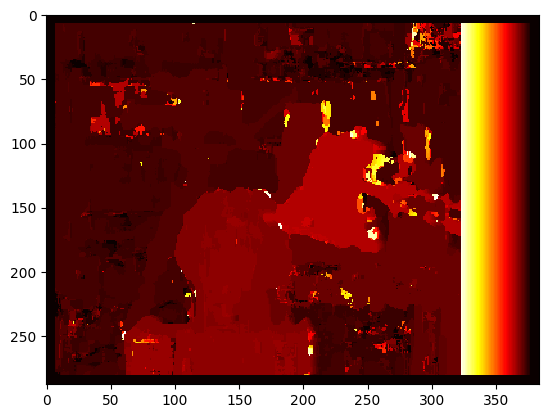

In [40]:
plt.imshow(disparity_map, cmap='hot', interpolation='nearest')


###  Can you make it better using the first excersise?
 - We can use SIFT+RANSAC to achieve better results

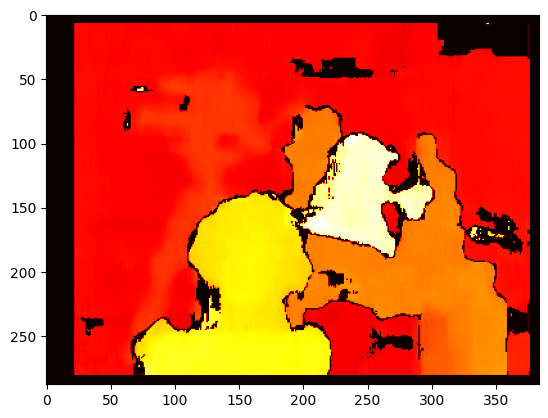

In [ ]:
imgL = cv2.imread('./images/tsukuba_l.png',0)
imgR = cv2.imread('./images/tsukuba_r.png',0)

stereo = cv2.StereoBM_create(numDisparities= 16,blockSize=15)
disparity = stereo.compute(imgL,imgR)
plt.imshow(disparity,cmap='hot')
plt.show()